EROSION

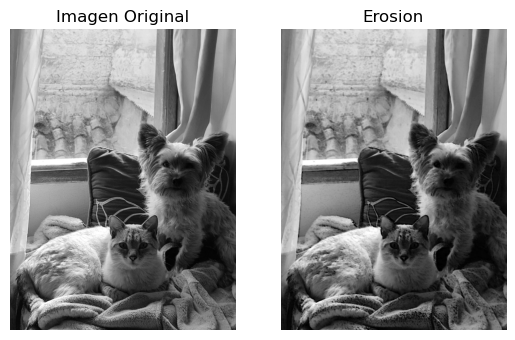

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('imagentango.jpg', cv2.IMREAD_GRAYSCALE)

#elemento estructurante
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

#aplicamos la erosion
img_erosion = cv2.erode(imagen, kernel)

plt.subplot(121)
plt.imshow(imagen, cmap='gray') 
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(122)
plt.imshow(img_erosion, cmap='gray')
plt.title('Erosion')
plt.axis('off')
plt.show()

dILATACION

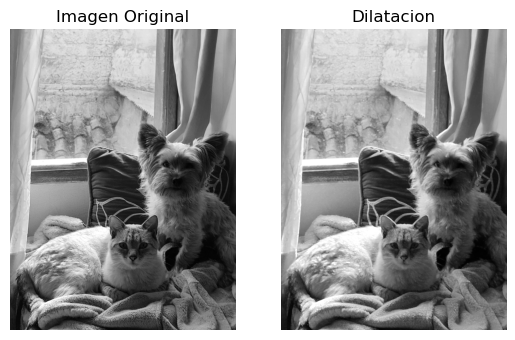

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


imagen=cv2.imread('imagentango.jpg', cv2.IMREAD_GRAYSCALE)

#elemento estructurante
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

#aplicamos la dilatacion
img_dilatacion = cv2.dilate(imagen, kernel)


plt.subplot(121)
plt.imshow(imagen, cmap='gray') 
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(122)    
plt.imshow(img_dilatacion, cmap='gray')
plt.title('Dilatacion')
plt.axis('off')
plt.show()

erosion binario

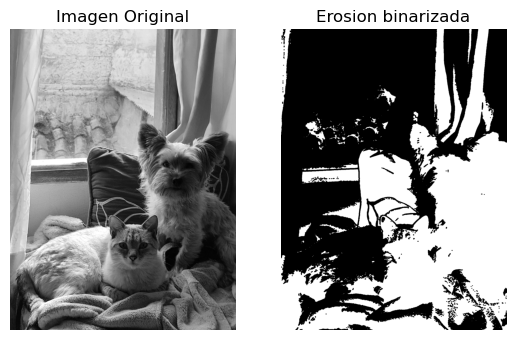

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


imagen=cv2.imread('imagentango.jpg', cv2.IMREAD_GRAYSCALE)
_, img_binarizada = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)  

#elemento estructurante
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

#aplicamos la dilatacion
img_erosionbin = cv2.erode(img_binarizada, kernel)


plt.subplot(121)
plt.imshow(imagen, cmap='gray') 
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(122)    
plt.imshow(img_erosionbin, cmap='gray')
plt.title('Erosion binarizada')
plt.axis('off')
plt.show()

dilatacion binaria

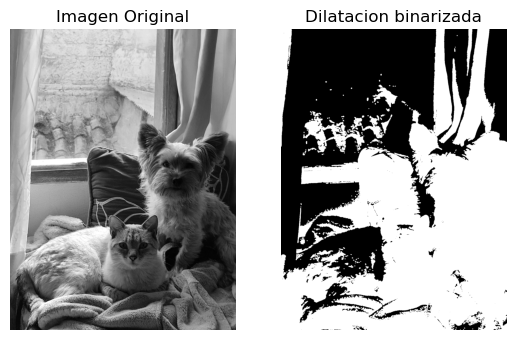

In [5]:
#dilatacion binarizada
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('imagentango.jpg', cv2.IMREAD_GRAYSCALE)
_, img_binarizada = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)

#elemento estructurante
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

#aplicamos la dilatacion
img_dilatacionbin = cv2.dilate(img_binarizada, kernel)

plt.subplot(121)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(122)
plt.imshow(img_dilatacionbin, cmap='gray')
plt.title('Dilatacion binarizada')
plt.axis('off')
plt.show()


apertura

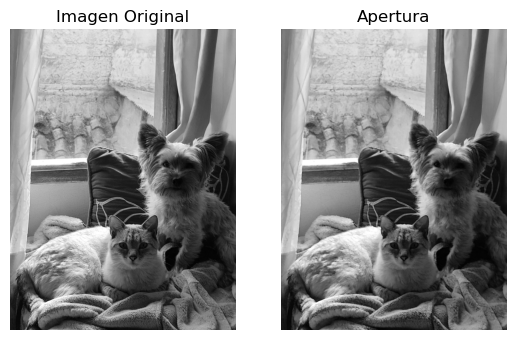

In [6]:
#apertura

import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('imagentango.jpg', cv2.IMREAD_GRAYSCALE)

#elemento estructurante
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

#aplicamos la erosion
#img_erosion = cv2.erode(imagen, kernel)

apertura = cv2.morphologyEx(imagen, cv2.MORPH_OPEN, kernel)

plt.subplot(121)
plt.imshow(imagen, cmap='gray') 
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(122)
plt.imshow(apertura, cmap='gray')
plt.title('Apertura')
plt.axis('off')
plt.show()


cerradura

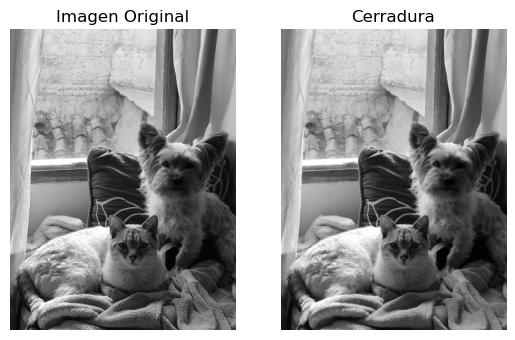

In [7]:
#cerradura
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('imagentango.jpg', cv2.IMREAD_GRAYSCALE)

#elemento estructurante
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

#aplicamos la erosion
#img_erosion = cv2.erode(imagen, kernel)

cerradura = cv2.morphologyEx(imagen, cv2.MORPH_CLOSE, kernel)

plt.subplot(121)
plt.imshow(imagen, cmap='gray') 
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(122)
plt.imshow(cerradura, cmap='gray')
plt.title('Cerradura')
plt.axis('off')
plt.show()




utilizar skimage con erosion dilatacion apertura y cerradura sin binarizar

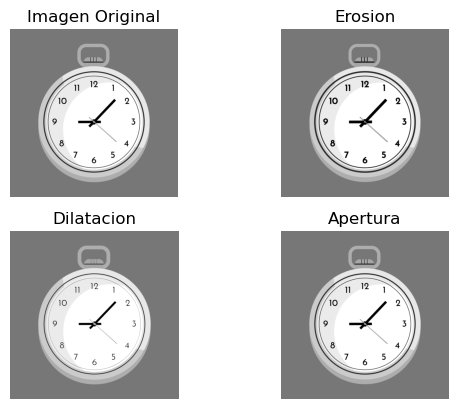

In [ ]:
#utilizar skimage con erosion, dilatacion, apertura y cerradura
# sin binarizar

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import morphology, measure


imagen=cv2.imread('reloj5.png', cv2.IMREAD_GRAYSCALE)
_, img_binarizada = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)

#elemento estructurante
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

#aplicamos la erosion
img_erosion = morphology.erosion(imagen, kernel)

#aplicamos la dilatacion
img_dilatacion = morphology.dilation(imagen, kernel)

#aplicamos la apertura
img_apertura = morphology.opening(imagen, kernel)

#aplicamos la cerradura
img_cerradura = morphology.closing(imagen, kernel)

#aplicamos la erosion binarizada
img_erosionbin = morphology.erosion(img_binarizada, kernel)

#aplicamos la dilatacion binarizada
img_dilatacionbin = morphology.dilation(img_binarizada, kernel)

plt.subplot(231)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(232)





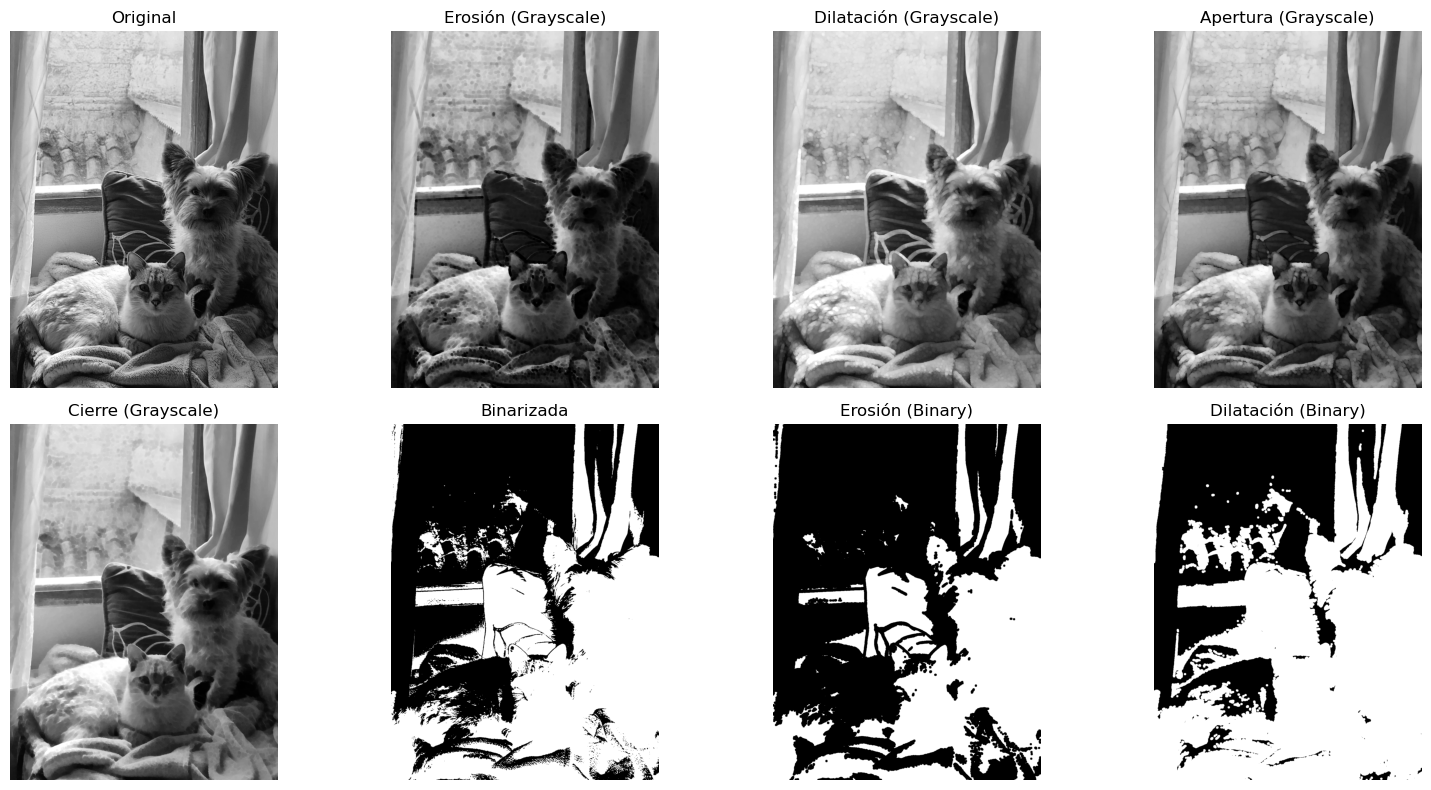

In [14]:
import cv2
import matplotlib.pyplot as plt
from skimage import morphology

# 1. Carga de la imagen (asegúrate de que 'reloj5.png' exista en tu directorio)
imagen = cv2.imread('imagentango.jpg', cv2.IMREAD_GRAYSCALE)
if imagen is None:
    raise FileNotFoundError("No se encontró 'reloj5.png'. Verifica la ruta y que el archivo exista.")

# 2. Creación del elemento estructurante (disco de radio 5)
selem = morphology.disk(5)

# 3. Operaciones morfológicas sobre la imagen en escala de grises
img_erosion      = morphology.erosion(imagen, selem)
img_dilation     = morphology.dilation(imagen, selem)
img_opening      = morphology.opening(imagen, selem)
img_closing      = morphology.closing(imagen, selem)

# 4. Binarización inversa para demostrar las operaciones binarias
_, img_binarizada  = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)
img_erosion_bin   = morphology.erosion(img_binarizada, selem)
img_dilation_bin  = morphology.dilation(img_binarizada, selem)

# 5. Visualización de resultados
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

titles = [
    'Original',
    'Erosión (Grayscale)',
    'Dilatación (Grayscale)',
    'Apertura (Grayscale)',
    'Cierre (Grayscale)',
    'Binarizada',
    'Erosión (Binary)',
    'Dilatación (Binary)'
]
images = [
    imagen,
    img_erosion,
    img_dilation,
    img_opening,
    img_closing,
    img_binarizada,
    img_erosion_bin,
    img_dilation_bin
]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


skimage simple

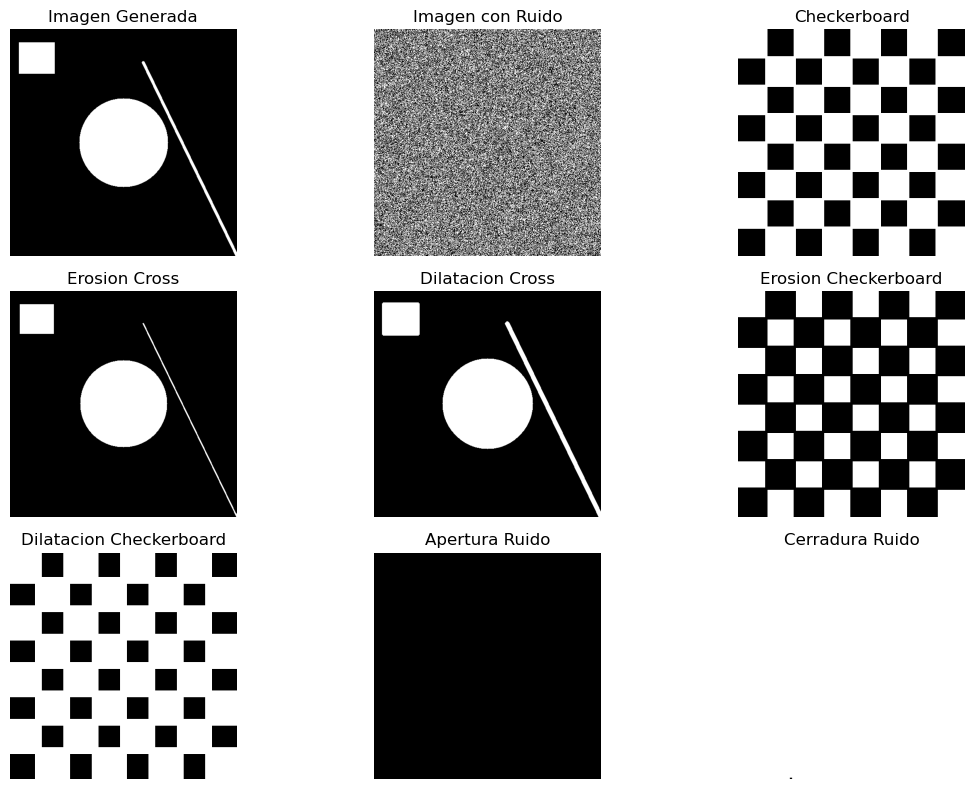

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage import morphology, measure
from skimage.data import checkerboard

imagen_generada = np.zeros((512, 512), dtype=np.uint8)
imagen_generada= cv2.circle(imagen_generada, (256, 256), 100, (255), -1)
imagen_generada= cv2.rectangle(imagen_generada, (20, 30), (100, 100), (255), -1)
imagen_generada= cv2.line(imagen_generada, (300, 75), (512, 512), (255), 5)

cheker= checkerboard()>0.5
cheker= cheker.astype(np.uint8)*255


kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))   
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

#aplicamos la erosion
erode_cross = cv2.erode(imagen_generada, kernel_cross, iterations=1)
dilate_cross = cv2.dilate(imagen_generada, kernel_cross, iterations=1)


erode_ellipse = cv2.erode(imagen_generada, kernel_ellipse, iterations=1)
dilate_ellipse = cv2.dilate(imagen_generada, kernel_ellipse, iterations=1)

erode_rect = cv2.erode(imagen_generada, kernel_rect, iterations=1)
dilate_rect = cv2.dilate(imagen_generada, kernel_rect, iterations=1)

erode_cheker = cv2.erode(cheker, kernel_ellipse, iterations=1)
dilate_cheker = cv2.dilate(cheker, kernel_ellipse, iterations=1)

#creamos imagen de apretura y cerradura
np.random.seed(42)
imagen_ruido = imagen_generada.copy()
ruido= np.random.randint(0, 2, imagen_generada.shape, dtype=np.uint8) * 255
imagen_ruido= cv2.bitwise_xor(imagen_ruido, ruido)

apertura_ruido = cv2.morphologyEx(imagen_ruido, cv2.MORPH_OPEN, kernel_rect)
cerradura_ruido = cv2.morphologyEx(imagen_ruido, cv2.MORPH_CLOSE, kernel_rect)

#mostrar los resultados
plt.figure(figsize=(12, 8))
plt.subplot(331)
plt.imshow(imagen_generada, cmap='gray')
plt.title('Imagen Generada')
plt.axis('off')

plt.subplot(332)
plt.imshow(imagen_ruido, cmap='gray')
plt.title('Imagen con Ruido')
plt.axis('off')

plt.subplot(333)
plt.imshow(cheker, cmap='gray')
plt.title('Checkerboard')
plt.axis('off')

plt.subplot(334)
plt.imshow(erode_cross, cmap='gray')
plt.title('Erosion Cross')
plt.axis('off')

plt.subplot(335)
plt.imshow(dilate_cross, cmap='gray')
plt.title('Dilatacion Cross')
plt.axis('off')

plt.subplot(336)
plt.imshow(erode_cheker, cmap='gray')
plt.title('Erosion Checkerboard')
plt.axis('off')

plt.subplot(337)
plt.imshow(dilate_cheker, cmap='gray')
plt.title('Dilatacion Checkerboard')
plt.axis('off')

plt.subplot(338)
plt.imshow(apertura_ruido, cmap='gray')
plt.title('Apertura Ruido')
plt.axis('off')

plt.subplot(339)
plt.imshow(cerradura_ruido, cmap='gray')

plt.title('Cerradura Ruido')
plt.axis('off')


plt.tight_layout()
plt.show()









transformada hit or miss

La transformada hit‐or‐miss es una operación morfológica que sirve para detectar patrones exactos en imágenes binarias. A cada posición del kernel, el píxel central “sale” como 1 solo si:

Todos los puntos marcados como “hit” (foreground) en el kernel coinciden con píxeles 1 en la imagen.

Todos los puntos marcados como “miss” (background) en el kernel coinciden con píxeles 0 en la imagen.

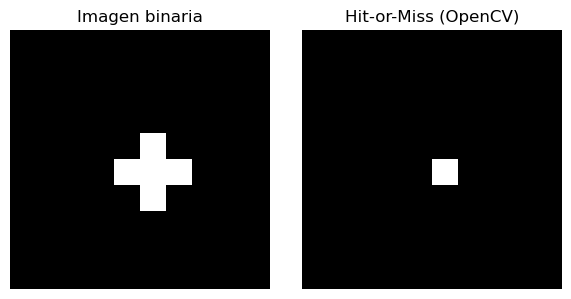

In [ ]:
#transformada hit or miss skimage

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import morphology, measure


img = np.zeros((10, 10), dtype=np.uint8)
# cruz
coords = [(5,5), (5,4), (5,6), (4,5), (6,5)]
for y,x in coords:
    img[y, x] = 1

# 2) kernel de hit-or-miss
# 1 = hit, 0 = don't care
kernel = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=np.uint8)

# 3) Aplicamos la transformada hit-or-miss
hitmiss = cv2.morphologyEx(img, cv2.MORPH_HITMISS, kernel)


plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.title('Imagen binaria')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(hitmiss, cmap='gray', vmin=0, vmax=1)
plt.title('Hit-or-Miss (OpenCV)')
plt.axis('off')
plt.tight_layout()
plt.show()


transformada hit or miss con opencv

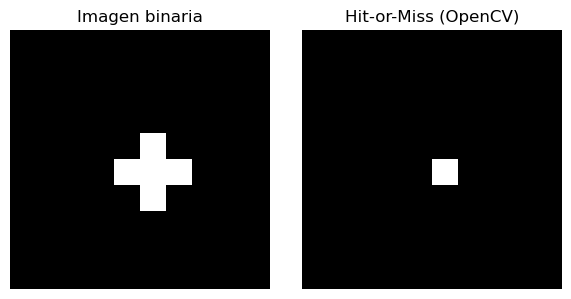

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1) Creamos una imagen de 10×10 con una cruz en el centro
img = np.zeros((10, 10), dtype=np.uint8)
# dibuja la cruz
coords = [(5,5), (5,4), (5,6), (4,5), (6,5)]
for y,x in coords:
    img[y, x] = 1

# 2) Definimos el kernel (se=structuring element)
# 1 = hit, 0 = don't care
kernel = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=np.uint8)

# 3) Aplicamos hit-or-miss
hitmiss = cv2.morphologyEx(img, cv2.MORPH_HITMISS, kernel)

# 4) Visualizamos
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.title('Imagen binaria')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(hitmiss, cmap='gray', vmin=0, vmax=1)
plt.title('Hit-or-Miss (OpenCV)')
plt.axis('off')
plt.tight_layout()
plt.show()


transformada geodesicas

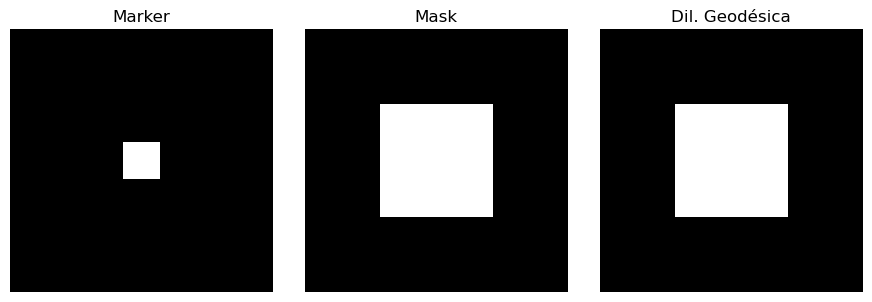

''

In [31]:
#transformada geodesica scikit-image

import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import reconstruction

# Imagen marker (donde inicia la propagación)
marker = np.zeros((7, 7), dtype=np.uint8)
marker[3, 3] = 1  # solo un punto activo

# Imagen máscara (límite)
mask = np.zeros((7, 7), dtype=np.uint8)
mask[2:5, 2:5] = 1  # una ventana de 3x3

# Reconstrucción por dilatación geodésica
result = reconstruction(marker, mask, method='dilation')

# Mostrar
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
titles = ['Marker', 'Mask', 'Dil. Geodésica']
for ax, img, title in zip(axs, [marker, mask, result], titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()
,
